# SafeSight — CLIP LoRA 파인튜닝 파이프라인

본 노트북은 실종 반려동물 검색 프로젝트 **SafeSight**의 핵심 모델 파이프라인입니다.

### 전체 구성
1. 패키지 설치
2. 데이터 로드 및 **Pet ID 기준 Train/Val/Test 분할**
3. FAISS 이미지 임베딩 DB 구축 (Train 데이터만 사용)
4. CLIP 베이스 모델 로드 및 LoRA 어댑터 적용
5. Contrastive Loss 기반 LoRA 파인튜닝
6. **Recall@K / mAP** 지표로 Zero-shot 대비 성능 평가



---
## 1. 패키지 설치

In [ ]:
# 패키지 설치
!pip install -U torchao transformers peft -q
!pip install faiss-cpu deep-translator tqdm -q

---
## 2. 라이브러리 임포트 및 기본 설정

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import faiss
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from transformers import CLIPProcessor, CLIPModel
from peft import LoraConfig, get_peft_model
from deep_translator import GoogleTranslator

# GPU 사용 가능하면 GPU, 아니면 CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 디바이스: {device}")

사용 디바이스: cuda


In [ ]:
import platform
import transformers
import peft

print("=" * 50)
print("개발 환경 세팅 확인")
print("=" * 50)

# Python 버전
print(f"Python       : {platform.python_version()}")

# PyTorch 버전 및 GPU
print(f"PyTorch      : {torch.__version__}")
print(f"CUDA 사용가능 : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"GPU 메모리   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f}GB")

# 라이브러리 버전
print(f"Transformers : {transformers.__version__}")
print(f"PEFT         : {peft.__version__}")
print(f"FAISS        : {faiss.__version__}")

print("=" * 50)
print("환경 세팅 확인 완료!")

개발 환경 세팅 확인
Python       : 3.12.13
PyTorch      : 2.11.0+cu128
CUDA 사용가능 : True
GPU          : Tesla T4
GPU 메모리   : 15.6GB
Transformers : 5.12.1
PEFT         : 0.19.1
FAISS        : 1.14.3
환경 세팅 확인 완료!


---
## 3. 경로 설정

Google Drive에 마운트된 데이터 경로를 설정합니다.  
본인 환경에 맞게 경로를 수정해주세요.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ---- 경로 설정  ----
BASE_DIR    = '/content/drive/MyDrive/SafeSight'
IMG_DIR     = f'{BASE_DIR}/data/raw/images'
META_PATH   = f'{BASE_DIR}/data/raw/metadata.csv'
EMBED_DIR   = f'{BASE_DIR}/data/embeddings'
MODEL_DIR   = f'{BASE_DIR}/models'

os.makedirs(EMBED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
print("경로 설정 완료")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
경로 설정 완료


---
## 4. 데이터 로드 및 Pet ID 기준 분할

### 왜 Pet ID 기준으로 분할하는가?

반려동물 데이터셋은 한 개체(Pet)당 **여러 장의 사진**이 존재합니다.  
만약 **랜덤으로 split**하면, 같은 개체의 사진 A는 Train에, 사진 B는 Test에 들어갈 수 있습니다.  
이 경우 모델이 해당 개체의 외형을 학습 중에 이미 '본' 상태가 되어 **Test 성능이 부풀려집니다.**

**Pet ID(desertionNo) 기준으로 분할**하면, 특정 개체는 Train/Val/Test 중 하나에만 속하므로  
Test에서는 모델이 한 번도 본 적 없는 완전히 새로운 개체만 평가하게 됩니다.

| 분할 방식 | 문제점 |
|---|---|
| 랜덤 split | 같은 개체가 Train/Test 양쪽에 등장 → 성능 부풀림 |
| **Pet ID 기준 split** | 개체 단위로 완전히 분리 → 진짜 일반화 성능 측정 가능 |

비율: Train 70% / Validation 15% / Test 15%

In [ ]:
# metadata 로드
metadata = pd.read_csv(META_PATH)
print(f"전체 데이터: {len(metadata)}개")
print(metadata.head(2))

# ── Pet ID(desertionNo) 기준으로 unique ID 추출 ──
unique_ids = metadata['desertionNo'].unique()
print(f"\n총 개체(Pet) 수: {len(unique_ids)}마리")

# ── Train 70% / 나머지 30% 분리 ──
train_ids, temp_ids = train_test_split(unique_ids, test_size=0.3, random_state=42)

# ── 나머지 30%를 Val 15% / Test 15% 로 분리 ──
val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

# ── ID 기준으로 실제 데이터프레임 분리 ──
train_meta = metadata[metadata['desertionNo'].isin(train_ids)].reset_index(drop=True)
val_meta   = metadata[metadata['desertionNo'].isin(val_ids)].reset_index(drop=True)
test_meta  = metadata[metadata['desertionNo'].isin(test_ids)].reset_index(drop=True)

# ── 누수(data leakage) 검증 ──
# 어떤 Pet ID도 두 개 이상의 split에 동시에 존재하면 안 됨
assert len(set(train_ids) & set(val_ids))  == 0, "Train-Val 누수 발생!"
assert len(set(train_ids) & set(test_ids)) == 0, "Train-Test 누수 발생!"
assert len(set(val_ids)   & set(test_ids)) == 0, "Val-Test 누수 발생!"

print(f"\n분할 결과 (누수 없음 확인 완료)")
print(f"  Train : {len(train_meta):5d}개 이미지 ({len(train_ids)}마리)")
print(f"  Val   : {len(val_meta):5d}개 이미지 ({len(val_ids)}마리)")
print(f"  Test  : {len(test_meta):5d}개 이미지 ({len(test_ids)}마리)")

전체 데이터: 4000개
       desertionNo kindNm colorCd  \
0  448567202600729    믹스견   옅은 황색   
1  448548202600502    믹스견      갈색   

                                         specialMark sexCd        happenPlace  \
0  119 포획, 마취총 맞고 입소, 헤진 목줄 착용, 아직 마취 덜 풀려서 성향 파악 못함     F  의창구 대산면 우암리 101-1   
1                                              마을배회      M             합천 소방서   

            orgNm processState  \
0  경상남도 창원시 의창성산구          보호중   
1        경상남도 합천군          보호중   

                                            popfile1  
0  http://openapi.animal.go.kr/openapi/service/re...  
1  http://openapi.animal.go.kr/openapi/service/re...  

총 개체(Pet) 수: 4000마리

분할 결과 (누수 없음 확인 완료)
  Train :  2800개 이미지 (2800마리)
  Val   :   600개 이미지 (600마리)
  Test  :   600개 이미지 (600마리)


---
## 5. HuggingFace CLIP 모델 및 프로세서 로드

LoRA 파인튜닝에는 HuggingFace의 `CLIPModel`을 사용합니다.  
이후 FAISS DB 구축, 검색, 평가 모두 이 모델 하나로 통일합니다.

> **기존 코드의 문제**: openai/clip 라이브러리(`model`)와 HuggingFace(`hf_model`)를 혼용하여,  
> LoRA로 파인튜닝해도 검색에 반영이 안 되는 구조였습니다. 이를 HuggingFace 단일 모델로 통일합니다.

In [ ]:
HF_MODEL_ID = "openai/clip-vit-base-patch32"

# 베이스 CLIP 모델 로드 (Zero-shot 평가용으로도 사용)
base_model = CLIPModel.from_pretrained(HF_MODEL_ID)
processor  = CLIPProcessor.from_pretrained(HF_MODEL_ID)

base_model.to(device)
print(f"CLIP 베이스 모델 로드 완료 | 디바이스: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP 베이스 모델 로드 완료 | 디바이스: cuda


---
## 6. FAISS 이미지 임베딩 DB 구축

FAISS는 대량의 이미지 임베딩 벡터를 저장하고 빠르게 유사도 검색을 수행하는 벡터 DB입니다.

**중요**: Train 데이터에 속하는 이미지만 FAISS DB에 넣습니다.  
Val/Test 이미지가 FAISS에 들어가면, 검색 시 모델이 '본 적 없어야 할' 개체를 알아보게 됩니다.

In [ ]:
# 기존 인덱스 파일 경로 설정
INDEX_FILE = f'{EMBED_DIR}/image_index.faiss'
MAP_FILE = f'{EMBED_DIR}/index_map.csv'

# 1. 파일 존재 여부 확인 및 로드
if os.path.exists(INDEX_FILE) and os.path.exists(MAP_FILE):
    print("기존 FAISS DB 파일을 발견했습니다. 저장된 인덱스를 불러옵니다.")
    index = faiss.read_index(INDEX_FILE)
    valid_ids_df = pd.read_csv(MAP_FILE)
    valid_ids = valid_ids_df['desertionNo'].tolist()
    print(f"로드 완료! 총 {len(valid_ids)}개의 이미지 인덱스가 준비되었습니다.")

else:
    print(f"기존 DB가 없습니다. 총 {len(train_ids_set)}장에 대해 FAISS DB 구축을 시작합니다.")

    base_model.eval()
    embeddings = []
    valid_ids = []

    for i, desertion_no in enumerate(train_ids_set):
        img_path = os.path.join(IMG_DIR, f"{desertion_no}.jpg")
        if not os.path.exists(img_path):
            continue
        try:
            image = Image.open(img_path).convert("RGB")
            inputs = processor(images=image, return_tensors="pt").to(device)

            with torch.no_grad():
                # CLIP 모델의 구조에 따라 올바른 feature 추출 방식 사용
                out = base_model.get_image_features(**inputs)
                emb = F.normalize(out, dim=-1)

                embeddings.append(emb.cpu().numpy())
                valid_ids.append(desertion_no)

        except Exception as e:
            print(f"실패: {desertion_no} → {e}")

        if (i + 1) % 100 == 0:
            print(f"  진행: {i+1}/{len(train_ids_set)}장 완료 (현재 성공 누적: {len(valid_ids)}장)")

    # FAISS 인덱스 생성
    embeddings_np = np.vstack(embeddings).astype('float32')
    index = faiss.IndexFlatIP(embeddings_np.shape[1])
    index.add(embeddings_np)

    # 파일 저장
    os.makedirs(EMBED_DIR, exist_ok=True)
    faiss.write_index(index, INDEX_FILE)
    pd.DataFrame({'desertionNo': valid_ids}).to_csv(MAP_FILE, index=False)
    print(f"\nFAISS DB 구축 완료! 총 {len(valid_ids)}개 저장 완료.")

기존 FAISS DB 파일을 발견했습니다. 저장된 인덱스를 불러옵니다.
로드 완료! 총 4003개의 이미지 인덱스가 준비되었습니다.


---
## STEP 7. Dataset 및 DataLoader 정의

PyTorch Dataset을 정의하고, Train/Val/Test 각각의 DataLoader를 생성합니다.

- `ShelterDataset`: 이미지 + 텍스트 프롬프트 쌍을 반환
- `collate_fn`: 배치 단위로 묶어 CLIP 프로세서 형식에 맞게 변환
- **shuffle=True는 Train만**, Val/Test는 순서를 유지해야 Recall@K 계산이 정확함

In [ ]:
import random
from torchvision import transforms

train_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

class ShelterDataset(Dataset):
    def __init__(self, metadata_df, img_dir, is_train=False):
        self.metadata = metadata_df
        self.img_dir  = img_dir
        self.is_train = is_train

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row          = self.metadata.iloc[idx]
        desertion_no = str(row['desertionNo'])
        img_path     = os.path.join(self.img_dir, f"{desertion_no}.jpg")

        try:
            image = Image.open(img_path).convert("RGB")
            if self.is_train:
                image = train_aug(image)
        except:
            image = Image.new("RGB", (224, 224), (255, 255, 255))


        kind  = row.get('kindNm', 'unknown breed')
        color = row.get('colorCd', '')

        templates = [
            "A photo of a {kind}. Color: {color}.",
            "A {color} {kind}.",
            "This is a {kind} with {color} fur.",
            "The image shows a  {kind} with {color} coat.",
            "A {kind}, color: {color}.",
            "Look at this {kind}. Color: {color}.",
            "A photo of a {kind} with {color} colored fur."
        ]

        if self.is_train:
            template = random.choice(templates)
        else:
            template = templates[1]

        text = template.format(kind=kind, color=color)
        return {"image": image, "text": text}


def collate_fn(batch):
    images = [item['image'] for item in batch]
    texts  = [item['text']  for item in batch]
    inputs = processor(
        images=images,
        text=texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77
    )
    return inputs


train_dataset = ShelterDataset(train_meta, IMG_DIR, is_train=True)
val_dataset   = ShelterDataset(val_meta,   IMG_DIR, is_train=False)
test_dataset  = ShelterDataset(test_meta,  IMG_DIR, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, collate_fn=collate_fn)

print(f"DataLoader 생성 완료")
print(f"  Train: {len(train_loader)}배치 | Val: {len(val_loader)}배치 | Test: {len(test_loader)}배치")

DataLoader 생성 완료
  Train: 350배치 | Val: 75배치 | Test: 75배치


In [ ]:
#데이터 증강
from torchvision import transforms

# train에만 적용할 증강
train_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

class ShelterDataset(Dataset):
    def __init__(self, metadata_df, img_dir, is_train=False):
        self.metadata = metadata_df
        self.img_dir  = img_dir
        self.is_train = is_train

    def __len__(self):
        return len(self.metadata)

def __getitem__(self, idx):
        row          = self.metadata.iloc[idx]
        desertion_no = str(row['desertionNo'])
        img_path     = os.path.join(self.img_dir, f"{desertion_no}.jpg")

        try:
            image = Image.open(img_path).convert("RGB")
            if self.is_train:
                image = train_aug(image)
        except:
            image = Image.new("RGB", (224, 224), (255, 255, 255))

        kind  = row.get('kindNm', 'unknown breed')
        color = row.get('colorCd', '')

        templates = [
            "A photo of a {kind}. Color: {color}.",
            "A {color} {kind}.",
            "This is a {kind} with {color} fur.",
            "The image shows a  {kind} with {color} coat.",
            "A {kind}, color: {color}.",
            "Look at this {kind}. Color: {color}.",
            "A photo of a {kind} with {color} colored fur."
        ]

        # 2. 학습 모드에 따른 텍스트 선택
        if self.is_train:
            template = random.choice(templates)
        else:
            # 평가 시에는 항상 첫 번째 혹은 일관된 템플릿 사용
            template = templates[1]

        # 3. 마지막에 .format()으로 최종 문장 생성
        text = template.format(kind=kind, color=color)

        return {"image": image, "text": text}

def collate_fn(batch):
    images = [item['image'] for item in batch]
    texts  = [item['text']  for item in batch]
    inputs = processor(
        images=images,
        text=texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77
    )
    return inputs


# Dataset 생성 (train만 is_train=True)
train_dataset = ShelterDataset(train_meta, IMG_DIR, is_train=True)
val_dataset   = ShelterDataset(val_meta,   IMG_DIR, is_train=False)
test_dataset  = ShelterDataset(test_meta,  IMG_DIR, is_train=False)

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, collate_fn=collate_fn)

print(f"DataLoader 생성 완료")
print(f"  Train: {len(train_loader)}배치 | Val: {len(val_loader)}배치 | Test: {len(test_loader)}배치")

DataLoader 생성 완료
  Train: 350배치 | Val: 75배치 | Test: 75배치


---
## STEP 8. LoRA 어댑터 적용

LoRA(Low-Rank Adaptation)는 모델 전체를 학습시키지 않고, 작은 어댑터 레이어만 추가로 학습하는 방법입니다.  
전체 파라미터의 1~5%만 학습하므로 메모리와 시간을 크게 절약할 수 있습니다.

| 설정 | 값 | 설명 |
|---|---|---|
| `r` | 8 | 저랭크 행렬의 랭크 (클수록 표현력↑, 파라미터↑) |
| `lora_alpha` | 16 | LoRA 스케일링 계수 (보통 r의 2배) |
| `target_modules` | q/k/v/out_proj | 어텐션 레이어에만 LoRA 적용 |
| `lora_dropout` | 0.05 | 과적합 방지 드롭아웃 |

In [ ]:
# LoRA 설정
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj"],
    lora_dropout=0.05,
    bias="none"
)

# 베이스 모델에 LoRA 어댑터 이식
lora_clip = get_peft_model(base_model, peft_config)
lora_clip.to(device)

# 학습 파라미터 수 출력 (전체 대비 몇 % 학습하는지 확인)
lora_clip.print_trainable_parameters()

trainable params: 983,040 || all params: 152,260,353 || trainable%: 0.6456


---
## STEP 9. Recall@K 평가 함수 정의

### Recall@K란?
텍스트 쿼리 N개에 대해, 정답 이미지가 상위 K개 결과 안에 들어오는 비율입니다.

**예시**: 테스트 쿼리 100개 중
- 정답 이미지가 Top-1 안에 42번 → **Recall@1 = 42%**
- 정답 이미지가 Top-5 안에 75번 → **Recall@5 = 75%**
- 정답 이미지가 Top-10 안에 82번 → **Recall@10 = 82%**

실종 반려동물 검색 서비스에서는 사용자가 검색 결과 상위 몇 개를 확인하므로,  
**Recall@1, @5, @10이 가장 중요한 지표**입니다.

### mAP (mean Average Precision)이란?
각 쿼리에 대해 정답이 얼마나 상위에 랭크되는지를 종합적으로 측정합니다.  
Recall@K보다 순위 정보를 더 세밀하게 반영합니다.

In [ ]:
def compute_metrics(model, loader, device, ks=[1, 5, 10]):
    model.eval()
    all_img_embs = []
    all_txt_embs = []

    with torch.no_grad():
        for batch in loader:
            inputs = {k: v.to(device) for k, v in batch.items()}

            img_out = model.vision_model(pixel_values=inputs['pixel_values'])
            img_emb = model.visual_projection(img_out.pooler_output)
            img_emb = F.normalize(img_emb, dim=-1)

            txt_out = model.text_model(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask']
            )
            txt_emb = model.text_projection(txt_out.pooler_output)
            txt_emb = F.normalize(txt_emb, dim=-1)

            all_img_embs.append(img_emb.cpu())
            all_txt_embs.append(txt_emb.cpu())

    all_img_embs = torch.cat(all_img_embs)
    all_txt_embs = torch.cat(all_txt_embs)
    N = len(all_txt_embs)
    sim_matrix = all_txt_embs @ all_img_embs.T

    results = {}
    for k in ks:
        k_actual = min(k, N)
        topk_indices = sim_matrix.topk(k_actual, dim=1).indices
        hits = sum(i in topk_indices[i].tolist() for i in range(N))
        results[f'R@{k}'] = hits / N * 100

    ap_list = []
    ranked = sim_matrix.argsort(dim=1, descending=True)
    for i in range(N):
        rank = (ranked[i] == i).nonzero(as_tuple=True)[0].item()
        ap_list.append(1.0 / (rank + 1))
    results['mAP'] = np.mean(ap_list) * 100
    return results

---
## STEP 10. LoRA 파인튜닝 학습

### Contrastive Loss (대조 학습)란?
배치 안의 이미지-텍스트 쌍이 서로 올바르게 매칭되도록 학습합니다.
- `loss_img`: 이미지 → 올바른 텍스트를 찾도록
- `loss_txt`: 텍스트 → 올바른 이미지를 찾도록
- 둘의 평균을 최종 Loss로 사용 (양방향 대조 학습)

에폭마다 **Val 셋으로 Recall@K를 측정**하여 학습 추이를 모니터링합니다.

---
## STEP 11. 학습 곡선 시각화

Train Loss 감소와 Val Recall@K 변화를 시각화하여 학습이 제대로 이루어졌는지 확인합니다.

- Loss가 감소하면서 Recall@K가 올라가야 정상적인 학습입니다.
- Loss는 내려가지만 Recall이 오르지 않으면 과적합(Overfitting)을 의심해야 합니다.

---
## STEP 12. 최종 평가: Zero-shot CLIP vs LoRA Fine-tuned CLIP


비교 대상:
- **Zero-shot CLIP**: 파인튜닝 없는 원본 CLIP 모델
- **LoRA Fine-tuned CLIP**: SafeSight 데이터로 파인튜닝한 모델

이 비교를 통해 LoRA 파인튜닝이 실제로 얼마나 성능을 향상시켰는지 정량적으로 확인합니다.

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 1,966,080 || all params: 153,243,393 || trainable%: 1.2830
LoRA 파인튜닝 시작


Epoch  1/30: 100%|██████████| 350/350 [12:54<00:00,  2.21s/it, loss=1.0508]


Epoch  1/30 | Train Loss: 1.6825 | Val Loss: 1.7706 | LR: 5.00e-05
  최고 모델 저장! Val Loss: 1.7706 (Epoch 1)


Epoch  2/30: 100%|██████████| 350/350 [03:27<00:00,  1.68it/s, loss=1.2834]


...

Epoch 10/30 | Train Loss: 0.4660 | Val Loss: 1.2509 | LR: 5.00e-05
  개선 없음 (3/5)


Epoch 11/30: 100%|██████████| 350/350 [03:29<00:00,  1.67it/s, loss=0.3148]


Epoch 11/30 | Train Loss: 0.4524 | Val Loss: 1.2618 | LR: 2.50e-05
  개선 없음 (4/5)


Epoch 12/30: 100%|██████████| 350/350 [03:28<00:00,  1.68it/s, loss=0.4067]


Epoch 12/30 | Train Loss: 0.4004 | Val Loss: 1.2803 | LR: 2.50e-05
  개선 없음 (5/5)
  Early Stopping! 최고 성능: Epoch 7, Val Loss: 1.1918

파인튜닝 완료! 최고 모델: Epoch 7 | Val Loss: 1.1918


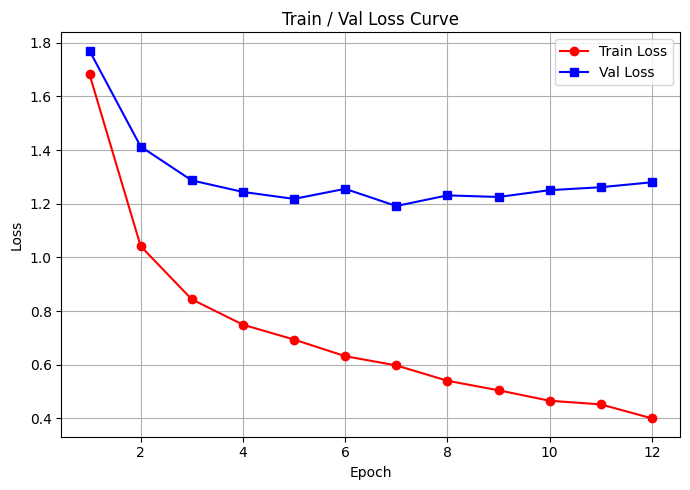

학습 곡선 저장 완료


In [ ]:
#데이터 증강
import gc
from transformers import CLIPModel

# ── LoRA 설정 ──
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj"],
    lora_dropout=0.05,
    bias="none"
)

# ── 베이스 모델에 LoRA 어댑터 이식 ──
lora_clip = get_peft_model(base_model, peft_config)
lora_clip.to(device)
lora_clip.print_trainable_parameters()

# ── 학습 설정 ──
MAX_EPOCHS = 30
PATIENCE   = 5

optimizer = optim.AdamW(lora_clip.parameters(), lr=5e-5, weight_decay=0.1)

# ReduceLROnPlateau: val_loss 개선 없으면 lr 자동으로 절반씩 줄임
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,     # 개선 없으면 lr × 0.5
    patience=3,     # 3번 연속 개선 없으면 lr 줄임
)

history          = {'train_loss': [], 'val_loss': []}
best_val_loss    = float('inf')
patience_counter = 0
best_epoch       = 0

print("LoRA 파인튜닝 시작\n" + "="*60)

for epoch in range(MAX_EPOCHS):
    # ── Train ──
    lora_clip.train()
    total_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:2d}/{MAX_EPOCHS}")
    for batch in pbar:
        inputs     = {k: v.to(device) for k, v in batch.items()}
        outputs    = lora_clip(**inputs)
        batch_size = outputs.logits_per_image.shape[0]
        labels     = torch.arange(batch_size, device=device)

        loss_img = F.cross_entropy(outputs.logits_per_image, labels)
        loss_txt = F.cross_entropy(outputs.logits_per_text,  labels)
        loss     = (loss_img + loss_txt) / 2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_loss)

    # ── Val Loss 계산 ──
    lora_clip.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            inputs     = {k: v.to(device) for k, v in batch.items()}
            outputs    = lora_clip(**inputs)
            batch_size = outputs.logits_per_image.shape[0]
            labels     = torch.arange(batch_size, device=device)
            loss_img   = F.cross_entropy(outputs.logits_per_image, labels)
            loss_txt   = F.cross_entropy(outputs.logits_per_text,  labels)
            total_val_loss += ((loss_img + loss_txt) / 2).item()

    avg_val_loss = total_val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)

    # lr 자동 조정 (val_loss 기준)
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1:2d}/{MAX_EPOCHS} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.2e}")

    # ── Early Stopping ──
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        best_epoch       = epoch + 1
        patience_counter = 0
        lora_clip.save_pretrained(f"{MODEL_DIR}/clip_lora_data")
        print(f"  최고 모델 저장! Val Loss: {best_val_loss:.4f} (Epoch {best_epoch})")
    else:
        patience_counter += 1
        print(f"  개선 없음 ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"  Early Stopping! 최고 성능: Epoch {best_epoch}, Val Loss: {best_val_loss:.4f}")
            break

print("\n" + "="*60)
print(f"파인튜닝 완료! 최고 모델: Epoch {best_epoch} | Val Loss: {best_val_loss:.4f}")


# ── 학습 곡선 시각화 ──
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 1, figsize=(7, 5))
axes.plot(epochs_range, history['train_loss'], marker='o', color='red',  label='Train Loss')
axes.plot(epochs_range, history['val_loss'],   marker='s', color='blue', label='Val Loss')
axes.set_title('Train / Val Loss Curve')
axes.set_xlabel('Epoch')
axes.set_ylabel('Loss')
axes.grid(True)
axes.legend()
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/training_curve_model2.png', dpi=150)
plt.show()
print("학습 곡선 저장 완료")



In [ ]:

# 2. 평가 루틴 (NameError 방지 및 정확한 비교)
from transformers import CLIPModel
from peft import PeftModel

# Zero-shot 평가용 깨끗한 모델
base_model_pure = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
base_model_pure.eval()

# LoRA 평가용 모델
hf_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
lora_clip_eval = PeftModel.from_pretrained(hf_model, f"{MODEL_DIR}/clip_lora_data")
lora_clip_eval.to(device)
lora_clip_eval.eval()

# 지표 계산
print("[1/2] Zero-shot CLIP 평가 중...")
zero_metrics = compute_metrics(base_model_pure, test_loader, device)

print("[2/2] LoRA Fine-tuned CLIP 평가 중...")
lora_metrics = compute_metrics(lora_clip_eval, test_loader, device)

# 결과 출력
print("\n" + "="*55)
print(f"{'지표':<10} {'Zero-shot':>14} {'LoRA Fine-tuned':>16} {'향상':>8}")
print("-" * 55)
for key in ['R@1', 'R@5', 'R@10', 'mAP']:
    z = zero_metrics[key]
    l = lora_metrics[key]
    diff = l - z
    arrow = "▲" if diff > 0 else "▼"
    print(f"{key:<10} {z:>13.1f}%  {l:>15.1f}%  {arrow}{abs(diff):>5.1f}%p")
print("="*55)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[1/2] Zero-shot CLIP 평가 중...
[2/2] LoRA Fine-tuned CLIP 평가 중...

지표              Zero-shot  LoRA Fine-tuned       향상
-------------------------------------------------------
R@1                  0.2%              3.8%  ▲  3.7%p
R@5                  0.2%             13.7%  ▲ 13.5%p
R@10                 1.0%             23.3%  ▲ 22.3%p
mAP                  0.9%             10.6%  ▲  9.6%p


---
## STEP 13. 검색 함수 (실제 서비스용)

파인튜닝된 LoRA 모델을 사용하여 한국어 텍스트로 반려동물 이미지를 검색합니다.  
FAISS DB에서 유사도 기준 상위 K개 결과를 반환합니다.

> **기존 코드의 문제**: search 함수가 원본 CLIP 모델(`model`)을 사용하고 있어  
> LoRA 파인튜닝 결과가 검색에 전혀 반영되지 않았습니다.  
> 이제 `lora_clip`을 사용하도록 수정합니다.

In [ ]:
# FAISS 인덱스 및 매핑 테이블 로드
index     = faiss.read_index(f'{EMBED_DIR}/image_index.faiss')
index_map = pd.read_csv(f'{EMBED_DIR}/index_map.csv')

CAT_KEYWORDS = ['한국 고양이', '묘', '코리안숏헤어', '페르시안',
                '러시안블루', '스핑크스', '랙돌', '샴']


def search(query, k=5, animal_type=None):
    """
    한국어 텍스트 쿼리로 반려동물 이미지를 검색합니다.

    Args:
        query (str): 검색 텍스트 (한국어 가능)
        k (int): 반환할 결과 수
        animal_type (str): '🐶 강아지' 또는 '🐱 고양이' 필터 (None이면 전체)

    Returns:
        list[dict]: 검색 결과 리스트
    """
    # 한국어 → 영어 번역 (CLIP은 영어 기반 모델)
    try:
        query_en = GoogleTranslator(source='ko', target='en').translate(query)
    except:
        query_en = query

    # 텍스트 임베딩 추출 (LoRA 파인튜닝된 모델 사용)
    lora_clip.eval()
    inputs = processor(text=[query_en], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        txt_emb = lora_clip.get_text_features(**inputs)
        txt_emb = F.normalize(txt_emb, dim=-1).cpu().numpy().astype('float32')

    # FAISS에서 유사도 높은 순으로 전체 검색
    similarities, indices = index.search(txt_emb, index.ntotal)

    results = []
    for sim, idx in zip(similarities[0], indices[0]):
        desertion_no = str(index_map.iloc[idx]['desertionNo'])
        meta_row = metadata[metadata['desertionNo'] == int(desertion_no)]
        if len(meta_row) == 0:
            continue
        meta = meta_row.iloc[0]

        # 종류 필터 적용
        is_cat = any(kw in str(meta['kindNm']) for kw in CAT_KEYWORDS)
        if animal_type == "🐶 강아지" and is_cat:
            continue
        if animal_type == "🐱 고양이" and not is_cat:
            continue

        results.append({
            "id":           desertion_no,
            "similarity":   round(float(sim) * 100, 1),
            "kindNm":       meta['kindNm'],
            "colorCd":      meta['colorCd'],
            "specialMark":  meta['specialMark'],
            "happenPlace":  meta['happenPlace'],
            "orgNm":        meta['orgNm'],
            "img_path":     f"{IMG_DIR}/{desertion_no}.jpg"
        })

        if len(results) >= k:
            break

    return results


# ── 검색 테스트 ──
test_results = search("갈색 털에 왼쪽 귀에 흉터가 있는 강아지", k=5, animal_type="🐶 강아지")
print(f"검색 결과 {len(test_results)}개")
for r in test_results:
    print(f"  ID: {r['id']} | 유사도: {r['similarity']}% | 종: {r['kindNm']}")

AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'norm'

In [ ]:
# 코랩에서 이거 실행해서 확인
import inspect
print(inspect.getsource(search))

def search(query, k=5, animal_type=None):
    """
    한국어 텍스트 쿼리로 반려동물 이미지를 검색합니다.

    Args:
        query (str): 검색 텍스트 (한국어 가능)
        k (int): 반환할 결과 수
        animal_type (str): '🐶 강아지' 또는 '🐱 고양이' 필터 (None이면 전체)

    Returns:
        list[dict]: 검색 결과 리스트
    """
    # 한국어 → 영어 번역 (CLIP은 영어 기반 모델)
    try:
        query_en = GoogleTranslator(source='ko', target='en').translate(query)
    except:
        query_en = query

    # 텍스트 임베딩 추출 (LoRA 파인튜닝된 모델 사용)
    lora_clip.eval()
    inputs = processor(text=[query_en], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        txt_emb = lora_clip.get_text_features(**inputs)
        txt_emb = F.normalize(txt_emb, dim=-1).cpu().numpy().astype('float32')

    # FAISS에서 유사도 높은 순으로 전체 검색
    similarities, indices = index.search(txt_emb, index.ntotal)

    results = []
    for sim, idx in zip(similarities[0], indices[0]):
        desertion_no = str(index_map.iloc[idx]['desertionNo'])
        meta_row = metadata[metada

In [ ]:
# FAISS 인덱스 및 매핑 테이블 로드
index     = faiss.read_index(f'{EMBED_DIR}/image_index.faiss')
index_map = pd.read_csv(f'{EMBED_DIR}/index_map.csv')

CAT_KEYWORDS = ['한국 고양이', '묘', '코리안숏헤어', '페르시안',
                '러시안블루', '스핑크스', '랙돌', '샴']


def search(query, k=5, animal_type=None):
    try:
        query_en = GoogleTranslator(source='ko', target='en').translate(query)
    except:
        query_en = query

    lora_clip.eval()
    inputs = processor(text=[query_en], return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        # ── 수정된 부분 ──
        txt_out = lora_clip.text_model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask']
        )
        txt_emb = lora_clip.text_projection(txt_out.pooler_output)
        txt_emb = F.normalize(txt_emb, dim=-1).cpu().numpy().astype('float32')

    similarities, indices = index.search(txt_emb, index.ntotal)

    results = []
    for sim, idx in zip(similarities[0], indices[0]):
        desertion_no = str(index_map.iloc[idx]['desertionNo'])
        meta_row = metadata[metadata['desertionNo'] == int(desertion_no)]
        if len(meta_row) == 0:
            continue
        meta = meta_row.iloc[0]

        is_cat = meta['upKindNm'] == '고양이'  # upKindNm으로 간단하게
        if animal_type == "🐶 강아지" and is_cat:
            continue
        if animal_type == "🐱 고양이" and not is_cat:
            continue

        results.append({
            "id":          desertion_no,
            "similarity":  round(float(sim) * 100, 1),
            "kindNm":      meta['kindNm'],
            "colorCd":     meta['colorCd'],
            "specialMark": meta['specialMark'],
            "happenPlace": meta['happenPlace'],
            "orgNm":       meta['orgNm'],
            "img_path":    f"{IMG_DIR}/{desertion_no}.jpg"
        })

        if len(results) >= k:
            break

    return results

In [ ]:
from peft import PeftModel
from transformers import CLIPModel

# 1. 베이스 모델 로드
base = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

# 2. LoRA 가중치 로드
lora_model = PeftModel.from_pretrained(base, f"{MODEL_DIR}/clip_lora_augmentation")

# 3. merge (베이스 모델에 LoRA 가중치 합치기)
merged_model = lora_model.merge_and_unload()

# 4. 합쳐진 모델 저장
merged_model.save_pretrained(f"{MODEL_DIR}/clip_merged")
processor.save_pretrained(f"{MODEL_DIR}/clip_merged")

print("merge 완료!")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

merge 완료!


In [ ]:
# 셀 1 — 설치
!pip install streamlit pyngrok deep-translator -q

!pip install ftfy regex tqdm -q
!pip install git+https://github.com/openai/CLIP.git -q
!pip install faiss-cpu -q
!pip install ultralytics deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.8 MB/s eta 0:00:00


In [ ]:
from pyngrok import ngrok
ngrok.kill()
print("✅ 기존 터널 종료 완료!")

✅ 기존 터널 종료 완료!


In [ ]:
%%writefile requirements.txt
streamlit
pillow
torch
torchvision
scikit-learn
open_clip_torch
faiss-cpu
pandas
numpy
deep_translator

Overwriting requirements.txt


In [ ]:
%%writefile app/streamlit_ui.py
import streamlit as st
import torch
import torch.nn.functional as F
import faiss
import numpy as np
import pandas as pd
from PIL import Image
import os
from deep_translator import GoogleTranslator
from ultralytics import YOLO
from transformers import CLIPModel, CLIPProcessor
from peft import PeftModel

@st.cache_resource
def load_model():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    MODEL_DIR = '/content/drive/MyDrive/SafeSight/models'

    base_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor  = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    lora_model = PeftModel.from_pretrained(base_model, f"{MODEL_DIR}/clip_lora_augmentation")
    lora_model.to(device)
    lora_model.eval()

    yolo_model = YOLO("yolov8n.pt")
    return lora_model, processor, yolo_model, device

@st.cache_resource
def load_db():
    index = faiss.read_index(
        '/content/drive/MyDrive/SafeSight/data/embeddings/image_index.faiss'
    )
    index_map = pd.read_csv(
        '/content/drive/MyDrive/SafeSight/data/embeddings/index_map.csv'
    )
    metadata = pd.read_csv(
        '/content/drive/MyDrive/SafeSight/data/raw/metadata.csv'
    )
    return index, index_map, metadata

lora_model, processor, yolo_model, device = load_model()
index, index_map, metadata = load_db()
IMG_DIR = '/content/drive/MyDrive/SafeSight/data/raw/images'

CAT_KEYWORDS = ['고양이', '묘', '코리안숏헤어', '페르시안', '러시안블루', '스핑크스', '랙돌', '샴']

def search(query=None, pil_img=None, k=5, animal_type=None):
    with torch.no_grad():
        if pil_img is not None:
            inputs  = processor(images=pil_img, return_tensors="pt").to(device)
            img_out = lora_model.vision_model(pixel_values=inputs['pixel_values'])
            emb     = lora_model.visual_projection(img_out.pooler_output)
            emb_np  = F.normalize(emb, dim=-1).cpu().numpy().astype('float32')
        else:
            try:
                query_en = GoogleTranslator(source='ko', target='en').translate(query)
            except:
                query_en = query
            inputs  = processor(text=[query_en], return_tensors="pt", padding=True).to(device)
            txt_out = lora_model.text_model(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask']
            )
            emb    = lora_model.text_projection(txt_out.pooler_output)
            emb_np = F.normalize(emb, dim=-1).cpu().numpy().astype('float32')

    total = index.ntotal
    similarities, indices = index.search(emb_np, total)

    results = []
    for sim, idx in zip(similarities[0], indices[0]):
        desertion_no = index_map.iloc[idx]['desertionNo']
        meta_row = metadata[metadata['desertionNo'] == int(desertion_no)]
        if len(meta_row) == 0:
            continue
        meta = meta_row.iloc[0]

        if animal_type == "🐶 강아지":
            if any(cat in str(meta['kindNm']) for cat in CAT_KEYWORDS):
                continue
        if animal_type == "🐱 고양이":
            if not any(cat in str(meta['kindNm']) for cat in CAT_KEYWORDS):
                continue

        results.append({
            "id": str(desertion_no),
            "similarity": round(float(sim) * 100, 1),
            "kindNm": meta['kindNm'],
            "colorCd": meta['colorCd'],
            "specialMark": meta['specialMark'],
            "happenPlace": meta['happenPlace'],
            "orgNm": meta['orgNm'],
            "img_path": f"{IMG_DIR}/{desertion_no}.jpg"
        })

        if len(results) >= k:
            break

    return results

if "page" not in st.session_state:
    st.session_state.page = "main"
if "query" not in st.session_state:
    st.session_state.query = ""
if "animal_type" not in st.session_state:
    st.session_state.animal_type = ""
if "results" not in st.session_state:
    st.session_state.results = []
if "cropped_img_path" not in st.session_state:
    st.session_state.cropped_img_path = None

def main_page():
    st.title("🐾 SafeSight")
    st.caption("놓치지 않는 시선, 연결되는 안전")
    st.divider()

    animal_type = st.radio(
        "동물 종류",
        ["🐶 강아지", "🐱 고양이"],
        horizontal=True
    )

    st.divider()
    st.subheader("🔍 인상착의 입력")
    query = st.text_input(
        "찾는 반려동물 특징을 입력하세요",
        placeholder="예: 흰색 말티즈 빨간 목줄 착용"
    )

    st.subheader("📸 사진 업로드")
    image = st.file_uploader(
        "또는 사진으로 검색",
        type=["jpg", "jpeg", "png"]
    )
    if image:
        st.image(image, caption="업로드된 사진", width=200)

    st.divider()

    if st.button("🔍 탐색 시작", use_container_width=True):
        if not query and not image:
            st.warning("⚠️ 특징을 입력하거나 사진을 업로드해주세요!")
        else:
            with st.spinner("🔍 탐색 중..."):
                if image is not None:
                    input_image = Image.open(image)
                    yolo_results = yolo_model(input_image)
                    cropped_image = None

                    for res in yolo_results:
                        for box in res.boxes:
                            cls_id = int(box.cls[0])
                            if cls_id in [15, 16]:
                                x1, y1, x2, y2 = map(int, box.xyxy[0])
                                cropped_image = input_image.crop((x1, y1, x2, y2))
                                break

                    if cropped_image is None:
                        cropped_image = input_image

                    results = search(pil_img=cropped_image, animal_type=animal_type)

                    os.makedirs("app", exist_ok=True)
                    cropped_image.save("app/temp_crop.jpg")
                    st.session_state.cropped_img_path = "app/temp_crop.jpg"
                else:
                    results = search(query=query, animal_type=animal_type)
                    st.session_state.cropped_img_path = None

            st.session_state.page = "result"
            st.session_state.query = query if query else "업로드된 이미지 기준 검색"
            st.session_state.animal_type = animal_type
            st.session_state.results = results
            st.rerun()

def result_page():
    if st.button("← 뒤로가기"):
        st.session_state.page = "main"
        st.rerun()

    st.title("검색 결과")

    col1, col2 = st.columns([4, 1])
    with col1:
        st.caption(f'🔍 "{st.session_state.query}"')
        st.caption(f'🐾 {st.session_state.animal_type}')
    with col2:
        st.metric("검색 건수", f"{len(st.session_state.results)}건")

    if st.session_state.cropped_img_path and os.path.exists(st.session_state.cropped_img_path):
        st.image(st.session_state.cropped_img_path, caption="YOLOv8 탐지 및 크롭 영역", width=150)

    st.divider()

    for result in st.session_state.results:
        with st.container(border=True):
            col1, col2 = st.columns([3, 1])

            with col1:
                try:
                    st.image(result['img_path'], width=100)
                except:
                    st.write("🐾")

                st.markdown(f"**공고 #{result['id']}**")
                st.caption(f"📍 {result['happenPlace']} ({result['orgNm']})")

                tag_html = " ".join([
                    f'<span style="background:#e6f1fb;padding:2px 8px;border-radius:10px;font-size:12px;margin-right:4px">{result["kindNm"]}</span>',
                    f'<span style="background:#eaf3de;padding:2px 8px;border-radius:10px;font-size:12px;margin-right:4px">{result["colorCd"]}</span>',
                ])
                st.markdown(tag_html, unsafe_allow_html=True)
                st.caption(f"특징: {result['specialMark']}")

            with col2:
                score = result["similarity"]
                color = "#185fa5" if score >= 50 else "#854f0b"
                st.markdown(
                    f'<div style="text-align:right;font-size:24px;font-weight:bold;color:{color}">{score}%</div>',
                    unsafe_allow_html=True
                )
                st.progress(score / 100)

if st.session_state.page == "main":
    main_page()
elif st.session_state.page == "result":
    result_page()

Overwriting app/streamlit_ui.py


In [ ]:
import subprocess, threading, time

def run():
    subprocess.Popen([
        "streamlit", "run", "app/streamlit_ui.py",
        "--server.port", "8501",
        "--server.headless", "true"
    ])

threading.Thread(target=run).start()
time.sleep(8)  # 8초 대기 (CLIP 로드 시간 필요)
print("✅ Streamlit 실행 완료!")

✅ Streamlit 실행 완료!


In [ ]:
from pyngrok import ngrok
ngrok.kill()

In [ ]:
# 셀 4 — ngrok 연결 (Streamlit 실행 후에!)
from pyngrok import ngrok
ngrok.set_auth_token("토큰")

public_url = ngrok.connect(8501)
print(f"✅ 접속 URL: {public_url}")

✅ 접속 URL: NgrokTunnel: "https://charm-guy-degrease.ngrok-free.dev" -> "http://localhost:8501"


[1/4] Zero-shot CLIP 평가 중...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  완료! R@1: 0.2%
[2/4] LoRA r=8 평가 중...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  완료! R@1: 0.3%
[3/4] LoRA r=16 평가 중...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  완료! R@1: 0.3%
[4/4] LoRA r=16 + 데이터 증강 평가 중...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  완료! R@1: 0.5%

모델                                R@1    R@5    R@10    mAP
-----------------------------------------------------------------
Zero-shot CLIP (Baseline)        0.2%   0.2%    1.0%   0.9%
LoRA r=8                         0.3%   2.5%    3.7%   2.3%
LoRA r=16                        0.3%   2.2%    4.7%   2.2%
LoRA r=16 + 데이터 증강               0.5%   2.0%    4.0%   2.2%


/tmp/ipykernel_5334/2976339672.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels, fontsize=9, rotation=15, ha='right')
/tmp/ipykernel_5334/2976339672.py:116: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/2976339672.py:116: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/2976339672.py:116: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/2976339672.py:116: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/2976339672.py:116: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/2976339672.py:116

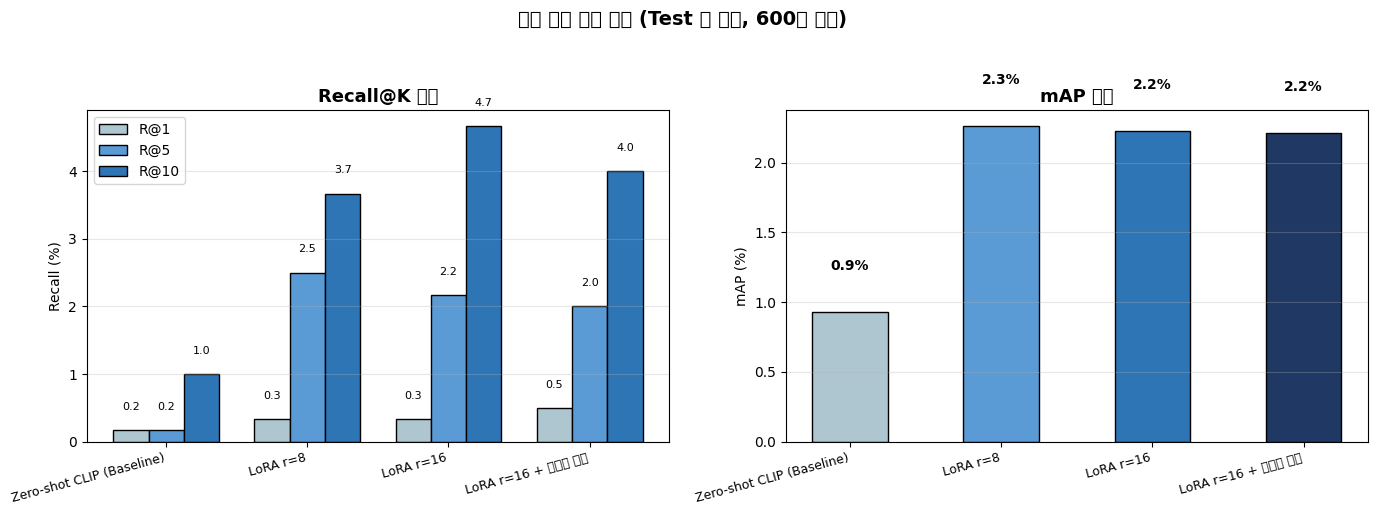


그래프 저장 완료: /content/drive/MyDrive/SafeSight/models/final_performance.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from transformers import CLIPModel
from peft import PeftModel

# ── 1. Zero-shot 평가 ──
print("[1/4] Zero-shot CLIP 평가 중...")
base_pure = CLIPModel.from_pretrained(HF_MODEL_ID).to(device)
base_pure.eval()

all_img_embs, all_txt_embs = [], []
with torch.no_grad():
    for batch in test_loader:
        inputs  = {k: v.to(device) for k, v in batch.items()}
        outputs = base_pure(**inputs)
        all_img_embs.append(F.normalize(outputs.image_embeds, dim=-1).cpu())
        all_txt_embs.append(F.normalize(outputs.text_embeds,  dim=-1).cpu())

all_img_embs = torch.cat(all_img_embs)
all_txt_embs = torch.cat(all_txt_embs)
N   = len(all_txt_embs)
sim = all_txt_embs @ all_img_embs.T

zero_metrics = {}
for k in [1, 5, 10]:
    topk = sim.topk(min(k, N), dim=1).indices
    hits = sum(i in topk[i].tolist() for i in range(N))
    zero_metrics[f'R@{k}'] = hits / N * 100
ranked = sim.argsort(dim=1, descending=True)
zero_metrics['mAP'] = np.mean(
    [1.0 / ((ranked[i]==i).nonzero(as_tuple=True)[0].item()+1) for i in range(N)]
) * 100
print(f"  완료! R@1: {zero_metrics['R@1']:.1f}%")

# ── 2. LoRA r=8 평가 ──
print("[2/4] LoRA r=8 평가 중...")
hf_r8   = CLIPModel.from_pretrained(HF_MODEL_ID)
lora_r8 = PeftModel.from_pretrained(hf_r8, f"{MODEL_DIR}/clip_lora_r8")
lora_r8.to(device)
lora_r8.eval()
r8_metrics = compute_metrics(lora_r8, test_loader, device)
print(f"  완료! R@1: {r8_metrics['R@1']:.1f}%")

# ── 3. LoRA r=16 평가 ──
print("[3/4] LoRA r=16 평가 중...")
hf_r16   = CLIPModel.from_pretrained(HF_MODEL_ID)
lora_r16 = PeftModel.from_pretrained(hf_r16, f"{MODEL_DIR}/clip_lora_r16")
lora_r16.to(device)
lora_r16.eval()
r16_metrics = compute_metrics(lora_r16, test_loader, device)
print(f"  완료! R@1: {r16_metrics['R@1']:.1f}%")

# ── 4. LoRA r=16 + 데이터 증강 평가 ──
print("[4/4] LoRA r=16 + 데이터 증강 평가 중...")
hf_aug   = CLIPModel.from_pretrained(HF_MODEL_ID)
lora_aug = PeftModel.from_pretrained(hf_aug, f"{MODEL_DIR}/clip_lora_augmentation")
lora_aug.to(device)
lora_aug.eval()
aug_metrics = compute_metrics(lora_aug, test_loader, device)
print(f"  완료! R@1: {aug_metrics['R@1']:.1f}%")

# ── 성능 비교표 출력 ──
experiments = [
    ("Zero-shot CLIP (Baseline)", zero_metrics),
    ("LoRA r=8",                  r8_metrics),
    ("LoRA r=16",                 r16_metrics),
    ("LoRA r=16 + 데이터 증강",    aug_metrics),
]

print("\n" + "="*65)
print(f"{'모델':<30} {'R@1':>6} {'R@5':>6} {'R@10':>7} {'mAP':>6}")
print("-"*65)
for name, m in experiments:
    print(f"{name:<30} {m['R@1']:>5.1f}% {m['R@5']:>5.1f}% {m['R@10']:>6.1f}% {m['mAP']:>5.1f}%")
print("="*65)

# ── 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels   = [e[0] for e in experiments]
r1_vals  = [e[1]['R@1']  for e in experiments]
r5_vals  = [e[1]['R@5']  for e in experiments]
r10_vals = [e[1]['R@10'] for e in experiments]
map_vals = [e[1]['mAP']  for e in experiments]
colors   = ['#AEC6CF', '#5B9BD5', '#2E75B6', '#1F3864']

# Recall@K 그룹 막대그래프
x     = np.arange(len(labels))
width = 0.25
axes[0].bar(x - width, r1_vals,  width, label='R@1',  color='#AEC6CF', edgecolor='black')
axes[0].bar(x,          r5_vals,  width, label='R@5',  color='#5B9BD5', edgecolor='black')
axes[0].bar(x + width,  r10_vals, width, label='R@10', color='#2E75B6', edgecolor='black')
axes[0].set_title('Recall@K 비교', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9, rotation=15, ha='right')
axes[0].set_ylabel('Recall (%)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (r1, r5, r10) in enumerate(zip(r1_vals, r5_vals, r10_vals)):
    axes[0].text(i - width, r1  + 0.3, f'{r1:.1f}',  ha='center', fontsize=8)
    axes[0].text(i,          r5  + 0.3, f'{r5:.1f}',  ha='center', fontsize=8)
    axes[0].text(i + width,  r10 + 0.3, f'{r10:.1f}', ha='center', fontsize=8)

# mAP 막대그래프
bars = axes[1].bar(labels, map_vals, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('mAP 비교', fontsize=13, fontweight='bold')
axes[1].set_ylabel('mAP (%)')
axes[1].set_xticklabels(labels, fontsize=9, rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, map_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('전체 실험 성능 비교 (Test 셋 기준, 600개 쿼리)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/final_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n그래프 저장 완료: {MODEL_DIR}/final_performance.png")


전체 600개 쿼리 중 Top-10 실패: 576개 (96.0%)


/tmp/ipykernel_5334/3393733802.py:87: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/3393733802.py:87: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/3393733802.py:87: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/3393733802.py:87: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/3393733802.py:87: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/3393733802.py:87: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/3393733802.py:87: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_l

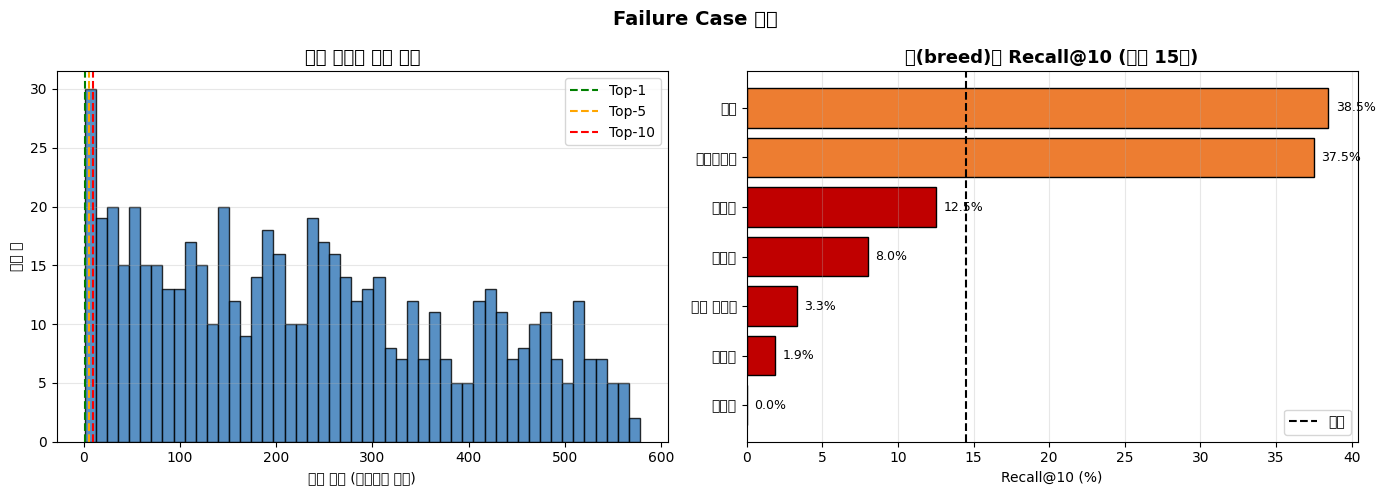

그래프 저장: /content/drive/MyDrive/SafeSight/models/failure_analysis.png

[실패 케이스 예시 - 정답이 Top-10 밖에 있는 케이스]


/tmp/ipykernel_5334/3393733802.py:141: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/3393733802.py:141: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/3393733802.py:141: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/3393733802.py:141: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/3393733802.py:141: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/3393733802.py:141: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5334/3393733802.py:141: UserWarning: Glyph 48121 (\N{HANGUL SYLLABLE MIG}) missing from font(s) DejaVu Sans.
  plt.

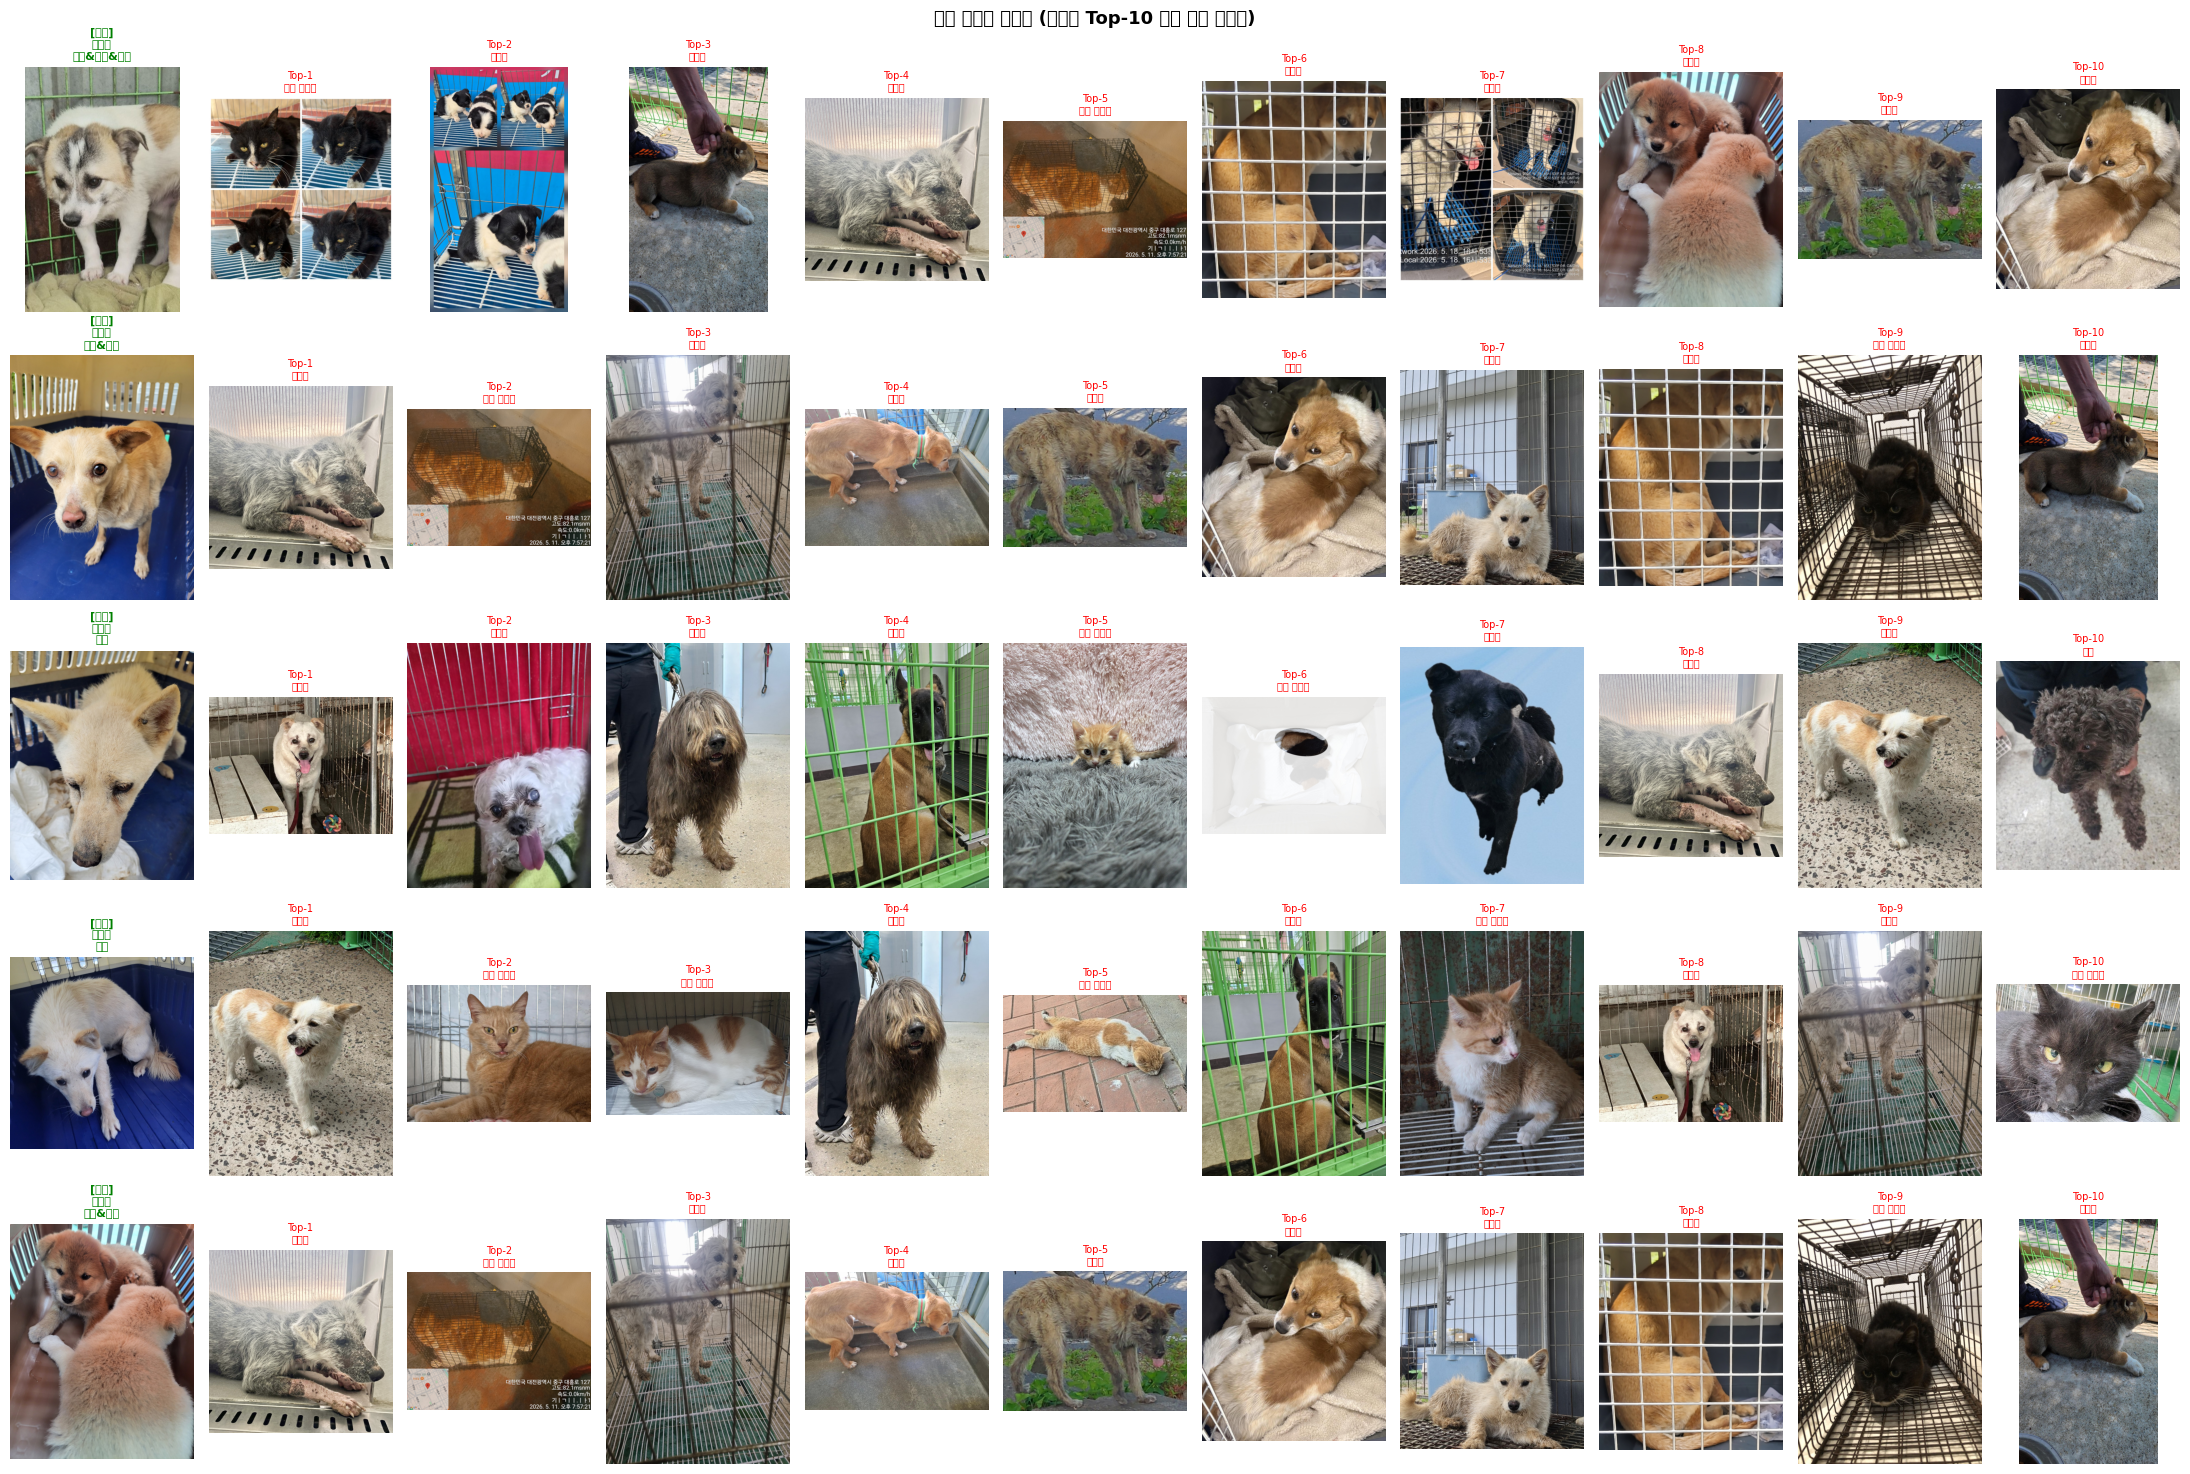

실패 케이스 이미지 저장: /content/drive/MyDrive/SafeSight/models/failure_cases.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

def failure_analysis(model, loader, test_meta, img_dir, device, top_k=10, num_samples=5):
    """
    실패 케이스 분석:
    - 정답 이미지가 Top-K 안에 없는 케이스를 찾아 시각화
    """
    model.eval()
    all_img_embs, all_txt_embs = [], []
    all_desertion_nos = list(test_meta['desertionNo'].astype(str))

    with torch.no_grad():
        for batch in loader:
            inputs  = {k: v.to(device) for k, v in batch.items()}
            img_out = model.vision_model(pixel_values=inputs['pixel_values'])
            img_emb = model.visual_projection(img_out.pooler_output)
            img_emb = F.normalize(img_emb, dim=-1)

            txt_out = model.text_model(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask']
            )
            txt_emb = model.text_projection(txt_out.pooler_output)
            txt_emb = F.normalize(txt_emb, dim=-1)

            all_img_embs.append(img_emb.cpu())
            all_txt_embs.append(txt_emb.cpu())

    all_img_embs = torch.cat(all_img_embs)
    all_txt_embs = torch.cat(all_txt_embs)
    N   = len(all_txt_embs)
    sim = all_txt_embs @ all_img_embs.T

    # ── 각 쿼리의 정답 순위 계산 ──
    ranked = sim.argsort(dim=1, descending=True)
    rank_list = []
    for i in range(N):
        rank = (ranked[i] == i).nonzero(as_tuple=True)[0].item() + 1
        rank_list.append(rank)

    # ── 실패 케이스: 정답이 Top-K 밖에 있는 케이스 ──
    fail_indices = [i for i, r in enumerate(rank_list) if r > top_k]
    print(f"\n전체 {N}개 쿼리 중 Top-{top_k} 실패: {len(fail_indices)}개 ({len(fail_indices)/N*100:.1f}%)")

    # ── 순위 분포 히스토그램 ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(rank_list, bins=50, color='#2E75B6', edgecolor='black', alpha=0.8)
    axes[0].axvline(x=1,  color='green',  linestyle='--', label='Top-1')
    axes[0].axvline(x=5,  color='orange', linestyle='--', label='Top-5')
    axes[0].axvline(x=10, color='red',    linestyle='--', label='Top-10')
    axes[0].set_title('정답 이미지 순위 분포', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('정답 순위 (낮을수록 좋음)')
    axes[0].set_ylabel('쿼리 수')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # ── 종(breed)별 성능 분석 ──
    kind_recall = {}
    for i in range(N):
        kind = test_meta.iloc[i]['kindNm']
        hit  = 1 if rank_list[i] <= top_k else 0
        if kind not in kind_recall:
            kind_recall[kind] = []
        kind_recall[kind].append(hit)

    # 샘플 수 5개 이상인 종만 추출, 성능 낮은 순 정렬
    kind_summary = {k: np.mean(v)*100 for k, v in kind_recall.items() if len(v) >= 5}
    kind_sorted  = sorted(kind_summary.items(), key=lambda x: x[1])[:15]

    kinds  = [k[0] for k in kind_sorted]
    scores = [k[1] for k in kind_sorted]
    colors = ['#C00000' if s < 30 else '#ED7D31' if s < 50 else '#2E75B6' for s in scores]

    axes[1].barh(kinds, scores, color=colors, edgecolor='black')
    axes[1].set_title(f'종(breed)별 Recall@{top_k} (하위 15종)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel(f'Recall@{top_k} (%)')
    axes[1].axvline(x=np.mean(scores), color='black', linestyle='--', label='평균')
    axes[1].legend()
    axes[1].grid(axis='x', alpha=0.3)
    for i, (k, s) in enumerate(zip(kinds, scores)):
        axes[1].text(s + 0.5, i, f'{s:.1f}%', va='center', fontsize=9)

    plt.suptitle('Failure Case 분석', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/failure_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"그래프 저장: {MODEL_DIR}/failure_analysis.png")

    # ── 실패 케이스 이미지 시각화 ──
    print(f"\n[실패 케이스 예시 - 정답이 Top-{top_k} 밖에 있는 케이스]")
    sample_fails = fail_indices[:num_samples]

    fig, axes = plt.subplots(num_samples, top_k+1, figsize=(22, num_samples*3))

    for row, i in enumerate(sample_fails):
        desertion_no = all_desertion_nos[i]
        meta         = test_meta.iloc[i]
        kind         = meta.get('kindNm', '')
        color        = meta.get('colorCd', '')
        actual_rank  = rank_list[i]

        # 정답 이미지 (맨 왼쪽)
        gt_path = os.path.join(img_dir, f"{desertion_no}.jpg")
        try:
            gt_img = mpimg.imread(gt_path)
            axes[row][0].imshow(gt_img)
        except:
            axes[row][0].text(0.5, 0.5, '이미지\n없음', ha='center', va='center')
        axes[row][0].set_title(f'[정답]\n{kind}\n{color}', fontsize=8, color='green', fontweight='bold')
        axes[row][0].axis('off')

        # Top-K 검색 결과
        topk_indices = ranked[i][:top_k].tolist()
        for col, pred_idx in enumerate(topk_indices):
            pred_no   = all_desertion_nos[pred_idx]
            pred_meta = test_meta.iloc[pred_idx]
            pred_path = os.path.join(img_dir, f"{pred_no}.jpg")

            try:
                pred_img = mpimg.imread(pred_path)
                axes[row][col+1].imshow(pred_img)
            except:
                axes[row][col+1].text(0.5, 0.5, '이미지\n없음', ha='center', va='center')

            is_correct = (pred_idx == i)
            title_color = 'green' if is_correct else 'red'
            axes[row][col+1].set_title(
                f'Top-{col+1}\n{pred_meta.get("kindNm","")}',
                fontsize=7, color=title_color
            )
            axes[row][col+1].axis('off')

        # 왼쪽에 실제 순위 표시
        axes[row][0].set_ylabel(f'실제 정답 순위: {actual_rank}위', fontsize=8, color='red')

    plt.suptitle(f'실패 케이스 시각화 (정답이 Top-{top_k} 밖에 있는 케이스)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/failure_cases.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"실패 케이스 이미지 저장: {MODEL_DIR}/failure_cases.png")


# ── 실행 ──
failure_analysis(
    model      = lora_aug,       # 평가할 모델 (lora_r8, lora_r16, lora_aug 중 선택)
    loader     = test_loader,
    test_meta  = test_meta,
    img_dir    = IMG_DIR,
    device     = device,
    top_k      = 10,             # Top-K 기준
    num_samples= 5               # 시각화할 실패 케이스 수
)